In [1]:
!pip install pillow --upgrade

In [2]:
# /content/drive/MyDrive/rokey/AI/application/6/Tuebingen_Neckarfront.jpg

# /content/drive/MyDrive/rokey/AI/application/6/vangogh_starry_night.jpg

In [3]:
# Python Imaging Library (PIL)의 Image 모듈을 불러옴. 이미지 파일을 열고 조작하는 데 사용함.
from PIL import Image

# Matplotlib의 pyplot 모듈을 plt 별칭으로 불러옴. 시각화에 사용함.
import matplotlib.pyplot as plt

# PyTorch 핵심 라이브러리를 불러옴.
import torch

# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn

# 옵티마이저(optim) 모듈을 불러옴.
import torch.optim as optim

# TorchVision 라이브러리를 불러옴. (이미지 변환 및 데이터셋 등에 사용)
import torchvision

# 학습에 사용할 장치(Device)를 설정함. CUDA(GPU)가 사용 가능하면 'cuda'를, 아니면 'cpu'를 선택함.
dvc = torch.device("cuda" if torch.cuda.is_available() else "cpu")

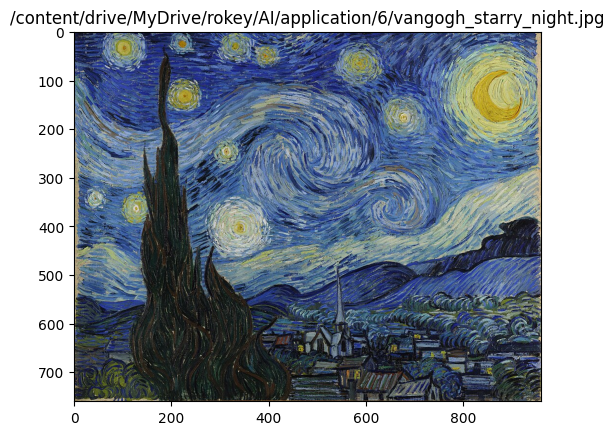

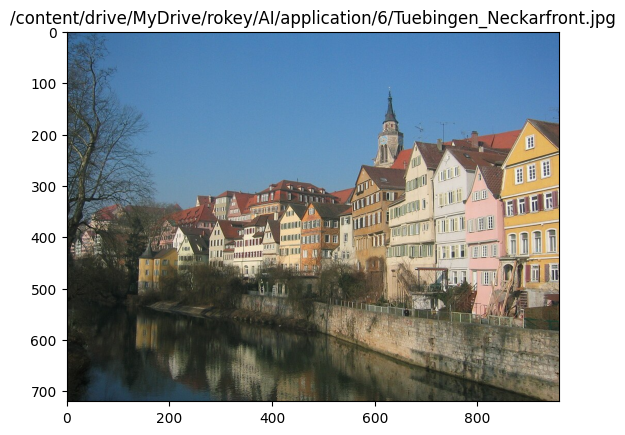

In [22]:
# 이미지 파일 열어 전처리 >> 텐서로 변환하는 함수 정의

def image_to_tensor(image_filepath, image_dimension=128):
  # image_dimension=128 기본값 128(최대 이미지 크기)
  img = Image.open(image_filepath).convert('RGB')

  # 디버깅 및 확인 위해 현재 이미지 >> matplotlib로 출력
  plt.figure()
  plt.title(image_filepath)
  plt.imshow(img)

  # 이미지 최대 해상도가 지정된 크기(image_dimension)보다 작거나 같으면 원본크기 사용
  if max(img.size) <= image_dimension:
    img_size = max(img.size)
  else: # 크다면 >> 지정된 크기 사용
    img_size = image_dimension

  # 이미지를 텐서 변환하기 위한 변환 파이프라인(compose)
  torch_transform = torchvision.transforms.Compose([
                          torchvision.transforms.Resize(img_size), # 이미지 크기 조정
                          torchvision.transforms.ToTensor() # 이미지를 텐서로 변환 (0~1 정규화)
                      ])

  # 정의된 변환을 이미지에 적용 >> 배치 차원 추가(차원 0)
  img = torch_transform(img).unsqueeze(0)
  # shape (chw) (3,h,w) >> (1,3,h,w) (**)

  # 텐서를 정의된 장치(GPU/CPU)와 데이터 타입(float) 변환
  return img.to(dvc, torch.float)

# 스타일 이미지 파일 열고 텐서로 변환
style_image = image_to_tensor('/content/drive/MyDrive/rokey/AI/application/6/vangogh_starry_night.jpg')
content_image = image_to_tensor('/content/drive/MyDrive/rokey/AI/application/6/Tuebingen_Neckarfront.jpg')



define gram matrix

In [5]:
# 입력 텐서의 gram matrix 계산 함수
def gram_matrix(ip):
  # 입력 텐서 4가지 차원(배치,채널,높이,너비) 추출
  num_batch, num_channels, height, width = ip.size()

  # 텐서의 공간차원(height*width) 하나의 벡터로 평탄화(flatten)
  # 그 결과 텐서 크기(num_batch*num_channels, width*height)
  feats = ip.view(num_batch*num_channels, height*width)
  # 4차원 >> 2차원 (1,64,128,128) >> (1*64, 128*128)

  # 평탄화된 특징(feats)과 그 전치(feats.t()) d의 행렬곱(torch.mm) 계산 >> gram matrix
  # 수식 : G = F * F.T >> 특징 벡터들(채널 정보)간의 내적 >> (C*C) 내적 >> (64,64)가 된다.
  # 어떤 특징들이 함께 나타나는가?
  gram_mat = torch.mm(feats, feats.t())

  # gram matrix를 텐서 요소의 총 개수(정규화 인자)로 나눠서 정규화
  # 정규화: 전체 요소의 개수로 나누기(이미지 크기에 관계없이 일정한 값 유지)
  return gram_mat.div(num_batch*num_channels*width*height)


pretrained model


In [6]:
vgg19_model = torchvision.models.vgg19(pretrained=True).to(dvc)

print(vgg19_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 82.0MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [8]:
vgg19_model.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [9]:
vgg19_model = vgg19_model.features

In [12]:
for p in vgg19_model.parameters():
  p.requires_grad = False
  # 해당 매개변수 p(parameter)에 대해 기울기(gradient) 계산 못하게 설정(freeze)

# 기울기 추적 비활성(꼼짝마 전략 필요 >> freeze)

refine model
- change maxpool layer to avgpool

In [13]:
# 합성곱 레이어의 인덱스를 저장한 빈 리스트 생성
conv_indices = []

# vgg19 model의 특징 추출 레이어들 (sequntial module) 순회
for i in range(len(vgg19_model)):
  # 현재 레이어의 이름이 'MaxPool2d'인 경우
  if vgg19_model[i]._get_name() == 'MaxPool2d':
    # MaxPool2d >> AvgPool2d 레이어로 교체
    # 왜? MaxPool은 그 region의 가장 큰 특징을 추출하는 기법인데 반하여
    # AvgPool은 더 부드러운 특징맵 생성
    # >> 스타일 전이할 때 품질을 향상시킬 수 있음!
    vgg19_model[i] = nn.AvgPool2d(kernel_size=vgg19_model[i].kernel_size,
                                  stride = vgg19_model[i].stride,
                                  padding=vgg19_model[i].padding)

  # 현재 레이어의 이름이 'Conv2d'인 경우
  if vgg19_model[i]._get_name() == 'Conv2d':
    conv_indices.append(i)
    # 해당 레이어의 인덱스(i) >> 리스트에 추가

conv_indices = dict(enumerate(conv_indices, 1)) # 리스트 값을 1부터 번호 붙여주는 것
# Conv2d인 레이어 인덱스를 1부터 순서 매긴 딕셔너리로 저장
# {1: 3, 2: 4, 3: 7...}

clip until the last relevant layer

In [14]:
layers = {1:'s', 2:'s', 3:'s', 4:'sc', 5:'s'}

In [24]:
vgg_layers = nn.ModuleList(vgg19_model)
vgg_layers
# vgg19 model의 특징 추출기(features) >> nn.ModuleList로 변환
# 원래 vgg19_model은 Sequential 구조
# 리스트로 바꾸면 인덱싱 슬라이싱 등 가능

# 이전에 수집한 합성곱 인덱스 딕셔너리(conv_indices)에서 가장 큰 인덱스 (가장 깊은 레이어)
last_layer_idx = conv_indices[max(conv_indices.keys())]

vgg_layers_trimmed = vgg_layers[:last_layer_idx+1]
# 마지막 합성곱 레이어까지 필요하니깐(+1) 하여 포함시켜서 잘라냄

# 잘라낸 레이어들을 nn.Sequential 모듈로 묶어 최종 모델 구성
# 이 모델은 이미지에서 스타일과 콘텐츠 특징을 추출하는 데 사용함
neural_style_transfer_model = nn.Sequential(*vgg_layers_trimmed) # *: 전부 다 쓰겠다
# *vgg_layers_trimmed: unpacking operator(언패킹 연산자) 리스트 요소를 하나씩 args(arguments)로 전달
print(neural_style_transfer_model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (19): Conv2d(256

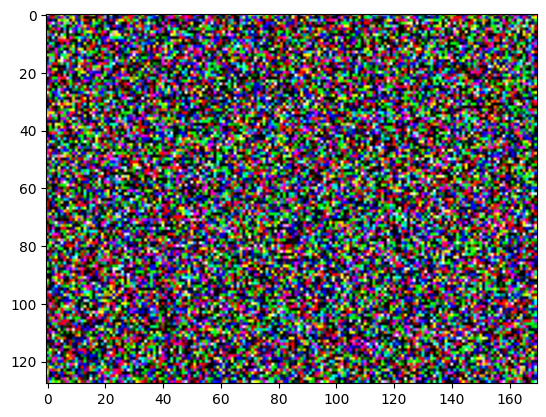

In [25]:
# 최적화 대상 이미지를 콘텐츠 이미지와 동일하게 초기화
# ip_image = content_image.clone()

# 최적화 대상(ip_image)를 콘텐츠 이미지 크기와 동일한 랜덤 노이즈로 초기화
ip_image = torch.randn(content_image.size(), device=dvc)

# 현재 초기화된 이미지(랜덤 노이즈) 시각화
plt.figure()
plt.imshow(ip_image.squeeze(0).cpu().detach().numpy().transpose(1,2,0).clip(0,1))
# 텐서에서 배치차원(0번) 제거, 기울기 비활성화, 넘파이 변환, 채널 순서 전치, 픽셀값 0~1 사이로 잘라서 출력


In [30]:
# 총 최적화 에폭(반복) 횟수를 300으로 설정
num_epochs = 300
# 스타일 손실에 부여할 가중치 설정 (일반적으로 콘텐츠 손실보다 훨씬 크게 설정)
# style loss Gram Matrix 기반 >> 값의 크기가 작게 나와요
# content loss보다 압도적으로 크게 설정해야 효과가 보여요
wt_style = 1e6

# 콘텐츠 손실 가중치 설정
wt_content = 1

# 각 에폭별 스타일/콘텐츠 손실 저장할 리스트 초기화
style_losses = []
content_losses = []

# optimizer 정의. 최적화 대상 ip_image, Adam 사용(lr=0.1 설정)
opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)

# 지정된 에폭 수 만큼 최적화 루츠 실행
for curr_epoch in range(1, num_epochs+1):
    ip_image.data.clamp_(0,1)
    # 생성된 이미지(ip_image)의 pixel 값을 [0,1] 범위 내로 강제함

    opt.zero_grad() #   gradient(변화도) 0으로 초기화

    # 현재 에폭의 스타일 손실/콘텐츠 손실 누적 변수를 0으로 초기화
    epoch_style_loss = 0
    epoch_content_loss = 0

    # 손실 계산할 레이어 인덱스(k) 순회
    for k in layers.keys():
      #레이어 k가 콘텐츠 손실('c')을 계산하는데 포함된 경우
      if 'c' in layers[k]:
        target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
        # 콘텐츠 이미지의 특징을 추출하고 변화도 계산에서 제외(detach)

        ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
        # 현재 이미지의 특징을 추출

        epoch_content_loss += torch.nn.functional.mse_loss(ip, target)
        # 콘텐츠 손실(mse)을 계산 >> 누적

      #레이어 k가 스타일 손실('s')을 계산하는데 포함된 경우
      if 's' in layers[k]:
        target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image)).detach()
        # 스타일 이미지의 하고 gram_matrix 계산 >> 변화도 계산에서 제외(detach)
        ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
        # 현재 이미지의  gram_matrix 계산

        epoch_style_loss += torch.nn.functional.mse_loss(ip, target)
        # 스타일 손실(mse)을 계산 >> 누적

    # 누적된 스타일 손실에 가중치(wt_style) 곱함
    epoch_style_loss *= wt_style

    # 누적된 콘텐츠 손실에 가중치(wt_content) 곱함
    epoch_content_loss *= wt_content

    # 최종 총 손실 계산
    total_loss = epoch_style_loss + epoch_content_loss

    # 역전파 수행 >> 총손실에 대한 변화도(gradient) 계산
    total_loss.backward()

    # 50 에폭마다 현재 상태를 출력하고 시각화함.
    if curr_epoch % 50 == 0:
        print(f"epoch number {curr_epoch}")
        print(f"style loss = {epoch_style_loss}, content loss = {epoch_content_loss}")
        plt.figure()
        plt.title(f"epoch number {curr_epoch}")
        # 생성된 이미지를 역변환(clamp, squeeze, numpy, transpose)하여 시각화함.
        plt.imshow(ip_image.data.clamp_(0, 1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
        plt.show()
        # 손실 값을 리스트에 저장함.
        style_losses.append(epoch_style_loss.item())
        content_losses.append(epoch_content_loss.item())

    # 옵티마이저를 사용하여 변화도 방향으로 이미지 픽셀 값을 업데이트함.
    opt.step()


Output hidden; open in https://colab.research.google.com to view.

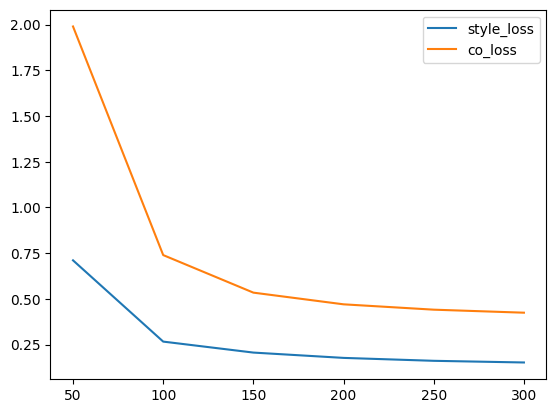

In [31]:
plt.plot(range(50, 300+1, 50), style_losses, label='style_loss')
plt.plot(range(50, 300+1, 50), content_losses, label='co_loss')
plt.legend()
plt.show()